# Skip-gram Manual (NumPy) — Vector Space Model Berita

**Alur (sesuai arahan dosen):**
1. Ambil data
2. Bersihkan data (buang simbol)
3. Hapus stopword
4. Tentukan jumlah kata unik
5. Skip-gram dengan `vector_size = 100`
6. Pembagian data: 200 berita → training 160, testing 40 (80:20)
7. Tampilkan Vector Space Model: **160 × 100**
8. Tambahkan label → **160 × 101 kolom**
9. *(Opsional)* Klasifikasi Naive Bayes dan evaluasi

> Skip-gram dibuat **manual dengan NumPy** (tanpa Gensim).
> Kolom teks dan label dideteksi otomatis; jika gagal, isi `TEXT_COL` dan `LABEL_COL` di cell konfigurasi.

## 0. Import & Konfigurasi

In [1]:
import re, os, time, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

# ===== KONFIGURASI =====
DATA_PATH   = "../data/dataset_berita_200.xlsx"
TEXT_COL    = None      # None = deteksi otomatis
LABEL_COL   = None      # None = deteksi otomatis

VECTOR_SIZE = 100       # sesuai dosen
WINDOW      = 5         # ukuran konteks (boleh diubah: 2, 3, 5, ...)
EPOCHS      = 10
NEG_SAMPLES = 5         # negative sampling
LR          = 0.05
BATCH_SIZE  = 2048
MAX_PAIRS   = None      # None = pakai semua pasangan; isi angka (mis. 200_000) agar lebih cepat
TEST_SIZE   = 0.20      # 200 data -> train 160, test 40

## 1. Ambil Data

In [2]:
df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)
print("Kolom:", df.columns.tolist())
df.head()

Shape: (200, 4)
Kolom: ['id', 'isi_berita', 'label', 'url']


,id,isi_berita,label,url
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,https://sport.detik.com/sport-lain/d-8655308/c...
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,https://sport.detik.com/sport-lain/d-8655303/a...
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,https://sport.detik.com/sport-lain/d-8655067/k...
3,4,Persaingan titel juara dunia semakin ketat men...,sport,https://sport.detik.com/moto-gp/d-8654776/moto...
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,https://sport.detik.com/raket/d-8654666/ganda-...


In [3]:
def find_col(candidates, cols):
    for cand in candidates:
        for c in cols:
            if cand in str(c).lower():
                return c
    return None

if TEXT_COL is None:
    TEXT_COL = find_col(["isi", "konten", "content", "teks", "text", "berita", "judul", "title"], df.columns)
if LABEL_COL is None:
    LABEL_COL = find_col(["kategori", "category", "label", "kanal", "topik"], df.columns)

print("Kolom teks  :", TEXT_COL)
print("Kolom label :", LABEL_COL)
assert TEXT_COL and LABEL_COL, "Isi TEXT_COL dan LABEL_COL secara manual di cell konfigurasi!"

df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
df.columns = ["teks", "label"]
print("Jumlah data:", len(df))
print(df["label"].value_counts())

Kolom teks  : isi_berita
Kolom label : label
Jumlah data: 200
label
sport      100
finance    100
Name: count, dtype: int64


## 2. Bersihkan Data (Buang Simbol)
Langkah: *lowercase* → hapus URL → buang simbol/tanda baca → pecah menjadi kata (tokenisasi).
Angka **dipertahankan** agar konteks (harga, skor, tahun) tidak hilang.

In [4]:
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)")

def bersihkan(teks):
    teks = str(teks).lower()                       # huruf kecil
    teks = URL_PATTERN.sub(" ", teks)              # hapus URL
    teks = re.sub(r"[^a-z0-9\s]", " ", teks)       # buang simbol (angka tetap)
    teks = re.sub(r"\s+", " ", teks).strip()       # rapikan spasi
    return teks

df["teks_bersih"] = df["teks"].apply(bersihkan)

print("SEBELUM:", df["teks"].iloc[0][:250], "...\n")
print("SESUDAH:", df["teks_bersih"].iloc[0][:250], "...")

SEBELUM: Chef de Mission (CdM) Indonesia Todotua Pasaribu terus memonitoring kondisi di Nagoya, Jepang jelang Asian Games 2026. Itu setelah adanya banjir besar yang menimpa kota tersebut.
Hal tersebut ditekankan Todo, sapaan karibnya, karena berkaitan dengan  ...

SESUDAH: chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games 2026 itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan konting ...


## 3. Hapus Stopword

In [5]:
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
    print("Sumber stopword: Sastrawi")
except Exception:
    try:
        import nltk
        nltk.download("stopwords", quiet=True)
        from nltk.corpus import stopwords
        STOPWORDS = set(stopwords.words("indonesian"))
        print("Sumber stopword: NLTK")
    except Exception:
        STOPWORDS = set("yang dan di ke dari untuk pada dengan ini itu adalah akan juga tidak dalam oleh atau sebagai karena telah sudah saat para ada mereka kami kita saya anda ia lebih dapat bisa hanya masih lagi".split())
        print("Sumber stopword: daftar bawaan (disarankan: pip install Sastrawi)")
print("Jumlah stopword:", len(STOPWORDS))

def hapus_stopword(teks):
    return [w for w in teks.split() if w not in STOPWORDS]

df["tokens"] = df["teks_bersih"].apply(hapus_stopword)

print("\nJumlah kata sebelum stopword:", df["teks_bersih"].str.split().str.len().sum())
print("Jumlah kata sesudah stopword :", df["tokens"].str.len().sum())
print("\nContoh token:", df["tokens"].iloc[0][:25])

Sumber stopword: Sastrawi
Jumlah stopword: 123

Jumlah kata sebelum stopword: 69050
Jumlah kata sesudah stopword : 53115

Contoh token: ['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'nagoya', 'jepang', 'jelang', 'asian', 'games', '2026', 'adanya', 'banjir', 'besar', 'menimpa', 'kota', 'tersebut', 'tersebut', 'ditekankan', 'todo']


## 4. Tentukan Jumlah Kata Unik

Total kata (token)      : 53115
Jumlah kata UNIK        : 7810


,kata,frekuensi
0,2026,481
1,indonesia,396
2,tersebut,374
3,menjadi,329
4,9,236
5,lebih,232
6,rp,220
7,tahun,198
8,hingga,191
9,harga,184


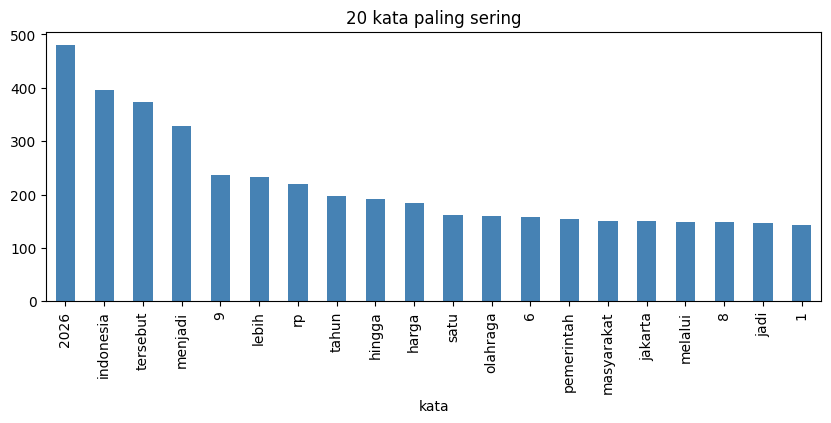

In [6]:
semua_kata = list(itertools.chain.from_iterable(df["tokens"]))
freq_all = Counter(semua_kata)

print("Total kata (token)      :", len(semua_kata))
print("Jumlah kata UNIK        :", len(freq_all))

top = pd.DataFrame(freq_all.most_common(20), columns=["kata", "frekuensi"])
display(top)
top.set_index("kata")["frekuensi"].plot(kind="bar", figsize=(10, 3.5), color="steelblue",
                                        title="20 kata paling sering")
plt.show()

## 5. Pembagian Data (Training 160 : Testing 40)
Stratified agar proporsi kelas seimbang. Skip-gram **hanya dilatih dari data training** supaya tidak ada kebocoran informasi dari data testing.

In [7]:
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED)

docs_train, y_train = df["tokens"].iloc[idx_train].tolist(), df["label"].iloc[idx_train].values
docs_test,  y_test  = df["tokens"].iloc[idx_test].tolist(),  df["label"].iloc[idx_test].values

print(f"Training: {len(docs_train)} | Testing: {len(docs_test)}")
print("\nDistribusi kelas:")
print(pd.DataFrame({"train": pd.Series(y_train).value_counts(),
                    "test":  pd.Series(y_test).value_counts()}))

Training: 160 | Testing: 40

Distribusi kelas:
         train  test
finance     80    20
sport       80    20


## 6. Skip-gram (vector_size = 100)

**Tahapan:** kata unik + ID → pasangan (kata pusat, kata konteks) lewat *sliding window* → pelatihan Skip-gram (Negative Sampling) → tabel bobot (vektor padat) tiap kata.

### 6.1 Kata Unik & ID (dari data training)

In [8]:
freq_train = Counter(w for d in docs_train for w in d)
id2word = [w for w, _ in freq_train.most_common()]
word2id = {w: i for i, w in enumerate(id2word)}
freq = np.array([freq_train[w] for w in id2word], dtype=np.float64)

print("Kata unik pada data training:", len(id2word))
print("Contoh ID:", {w: word2id[w] for w in id2word[:8]})

Kata unik pada data training: 6911
Contoh ID: {'2026': 0, 'indonesia': 1, 'tersebut': 2, 'menjadi': 3, 'lebih': 4, '9': 5, 'rp': 6, 'harga': 7}


### 6.2 Pasangan Kata Pusat & Kata Konteks (Sliding Window)

In [9]:
def make_pairs(docs_ids, window):
    centers, contexts = [], []
    for ids in docs_ids:
        n = len(ids)
        for off in range(1, window + 1):
            if n > off:
                centers  += [ids[:-off], ids[off:]]
                contexts += [ids[off:],  ids[:-off]]
    return np.concatenate(centers), np.concatenate(contexts)

# Demo pasangan pada 8 kata pertama dokumen pertama
demo = docs_train[0][:8]
print("Kata :", demo, f"(window={WINDOW})")
demo_pairs = [(demo[i], demo[j]) for i in range(len(demo))
              for j in range(max(0, i - WINDOW), min(len(demo), i + WINDOW + 1)) if i != j]
print("Contoh pasangan (pusat -> konteks):", demo_pairs[:8], "...")

docs_ids = [np.array([word2id[w] for w in d], dtype=np.int64) for d in docs_train if len(d) > 1]
centers, contexts = make_pairs(docs_ids, WINDOW)
print("\nTotal pasangan latih:", f"{len(centers):,}")

Kata : ['jakarta', 'bandara', 'halim', 'perdanakusuma', 'melayani', 'penerbangan', 'hari', 'ditutup'] (window=5)
Contoh pasangan (pusat -> konteks): [('jakarta', 'bandara'), ('jakarta', 'halim'), ('jakarta', 'perdanakusuma'), ('jakarta', 'melayani'), ('jakarta', 'penerbangan'), ('bandara', 'jakarta'), ('bandara', 'halim'), ('bandara', 'perdanakusuma')] ...

Total pasangan latih: 421,090


### 6.3 Pelatihan Skip-gram

vocab=6911 | dim=100 | pasangan/epoch=421,090
  epoch 1/10 | loss=3.4262 | lr=0.0450 | 9.8 dtk
  epoch 2/10 | loss=2.5744 | lr=0.0400 | 19.4 dtk
  epoch 3/10 | loss=2.3332 | lr=0.0350 | 30.8 dtk
  epoch 4/10 | loss=2.1501 | lr=0.0300 | 38.4 dtk
  epoch 5/10 | loss=2.0004 | lr=0.0250 | 47.2 dtk
  epoch 6/10 | loss=1.8751 | lr=0.0200 | 56.5 dtk
  epoch 7/10 | loss=1.7746 | lr=0.0150 | 64.2 dtk
  epoch 8/10 | loss=1.6957 | lr=0.0100 | 71.4 dtk
  epoch 9/10 | loss=1.6363 | lr=0.0050 | 78.3 dtk
  epoch 10/10 | loss=1.5992 | lr=0.0025 | 84.6 dtk


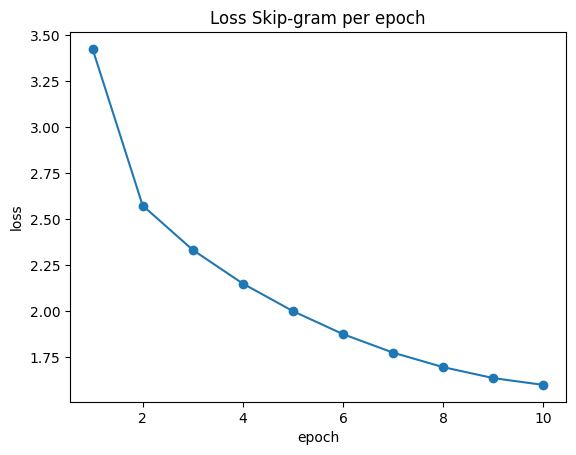

In [10]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

def scatter_add(M, idx, values):
    # M[idx] += values (idx boleh berulang); lebih cepat dari np.add.at
    S = csr_matrix((np.ones(len(idx)), (idx, np.arange(len(idx)))), shape=(M.shape[0], len(idx)))
    M += S @ values

def train_skipgram(centers, contexts, freq, vector_size, epochs=EPOCHS, neg=NEG_SAMPLES,
                   lr0=LR, batch=BATCH_SIZE, max_pairs=MAX_PAIRS, seed=SEED):
    rng = np.random.default_rng(seed)
    V, D = len(freq), vector_size

    # distribusi negative sampling ~ frekuensi^0.75
    p = freq ** 0.75; p /= p.sum()
    neg_table = np.repeat(np.arange(V), np.maximum((p * 200_000).astype(int), 1))

    W_in  = rng.uniform(-0.5 / D, 0.5 / D, (V, D))    # vektor kata (hasil akhir)
    W_out = np.zeros((V, D))                           # vektor konteks

    n_use = len(centers) if max_pairs is None else min(len(centers), max_pairs)
    total_steps = epochs * int(np.ceil(n_use / batch)); step = 0
    losses, t0 = [], time.time()
    print(f"vocab={V} | dim={D} | pasangan/epoch={n_use:,}")

    for ep in range(epochs):
        sel = rng.permutation(len(centers))[:n_use]
        c_all, o_all = centers[sel], contexts[sel]
        ep_loss = 0.0
        for s in range(0, n_use, batch):
            c, o = c_all[s:s + batch], o_all[s:s + batch]
            B = len(c)
            negs = neg_table[rng.integers(0, len(neg_table), (B, neg))]
            lr = lr0 * max(1 - step / total_steps, 0.05); step += 1

            v, u_pos, u_neg = W_in[c], W_out[o], W_out[negs]
            s_pos = sigmoid(np.sum(v * u_pos, axis=1))
            s_neg = sigmoid(np.einsum("bd,bkd->bk", v, u_neg))
            ep_loss += (-np.log(s_pos + 1e-9) - np.log(1 - s_neg + 1e-9).sum(1)).sum()

            g_pos, g_neg = s_pos - 1, s_neg
            grad_v = g_pos[:, None] * u_pos + np.einsum("bk,bkd->bd", g_neg, u_neg)
            scatter_add(W_out, o,            -lr * g_pos[:, None] * v)
            scatter_add(W_out, negs.ravel(), -lr * (g_neg[:, :, None] * v[:, None, :]).reshape(-1, D))
            scatter_add(W_in,  c,            -lr * grad_v)
        losses.append(ep_loss / n_use)
        print(f"  epoch {ep+1}/{epochs} | loss={losses[-1]:.4f} | lr={lr:.4f} | {time.time()-t0:.1f} dtk")
    return W_in, losses

W, losses = train_skipgram(centers, contexts, freq, VECTOR_SIZE)

plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.title("Loss Skip-gram per epoch"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

### 6.4 Tabel Bobot Kata (Vektor Padat)

In [11]:
dim_cols = [f"dim_{i+1}" for i in range(VECTOR_SIZE)]
df_kata = pd.DataFrame(W, index=id2word, columns=dim_cols)

print("Ukuran tabel bobot kata (kata unik x vector_size):", df_kata.shape)
df_kata.head(10)

Ukuran tabel bobot kata (kata unik x vector_size): (6911, 100)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,...,dim_91,dim_92,dim_93,dim_94,dim_95,dim_96,dim_97,dim_98,dim_99,dim_100
2026,-0.383230,-0.245606,0.741705,0.423942,-0.703510,0.781364,0.488528,0.726282,-0.646892,0.503859,...,0.097028,-0.376210,0.532257,0.167515,-0.230066,0.504323,-0.191355,-0.362502,-0.035928,1.440675
indonesia,0.870815,0.286114,-0.091848,0.947175,-0.002469,0.648816,0.139225,-0.341437,-0.841913,0.606725,...,0.205913,-0.080822,-0.709957,0.367106,-0.562337,-0.145941,-0.430335,-0.284612,-0.164799,0.193281
tersebut,-0.075590,0.206527,0.459579,0.012584,-0.833588,-0.791590,0.162115,-0.326145,-0.913934,0.155220,...,0.168476,-0.365038,0.705707,-0.786955,0.137445,0.243856,0.451993,-0.628208,0.614596,-0.058469
menjadi,0.484985,-0.675222,0.019266,0.983564,-0.155919,-0.407223,0.198816,0.161199,-0.713965,-0.888195,...,0.468761,-0.476335,-0.306662,0.500422,-0.317222,-0.189384,-0.076051,-0.496077,-0.547888,0.356991
lebih,-0.315309,-0.333353,0.088607,-0.761500,0.306165,1.005989,0.032600,0.415199,-0.695641,0.583722,...,0.533624,0.390674,-0.070615,0.219355,0.579902,0.583094,-0.495953,-0.583877,-0.239361,-0.205753
9,0.612556,0.114508,0.644201,-0.119577,-0.527868,0.755872,-0.046045,0.633711,-0.415887,0.515369,...,0.434595,0.239794,0.650032,-0.644686,-0.385723,-0.055381,-0.132670,0.254670,0.554090,0.931844
rp,0.236617,0.332262,0.541077,0.514441,0.006626,0.212061,1.340279,-0.040868,-0.304080,0.336379,...,-0.341948,0.779848,-0.394586,-0.223734,0.219240,0.067936,-0.068221,-0.610589,0.138951,-0.098632
harga,-0.363737,-0.886620,0.196585,0.477790,-0.023321,-0.134017,0.535359,0.559327,-1.068474,-0.298424,...,-1.465562,0.447099,-0.012656,-1.080065,0.482267,-0.049952,-0.435926,-0.337072,0.428279,0.755099
tahun,0.461386,0.068356,0.343904,0.480472,-0.682837,0.614356,0.709394,0.417751,-0.836734,0.418907,...,-0.656401,0.115978,0.056006,-0.398815,0.619932,0.707767,-0.919390,0.516407,0.088546,0.218329
hingga,0.362623,-0.348432,-0.701861,0.129699,0.394706,0.045227,0.733758,-0.321785,-0.339212,-0.316460,...,0.336232,0.029062,0.036171,-0.007453,-0.321820,0.543453,-0.221620,-0.732932,0.241867,0.171795


In [12]:
def most_similar(word, topn=5):
    Wn = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-9)
    sims = Wn @ Wn[word2id[word]]
    order = [i for i in np.argsort(-sims) if id2word[i] != word][:topn]
    return [(id2word[i], round(float(sims[i]), 2)) for i in order]

for w in [x for x in id2word if x.isalpha() and len(x) > 3][:5]:
    print(w, "->", most_similar(w))

indonesia -> [('bri', 0.52), ('syariah', 0.48), ('sapta', 0.47), ('oktohari', 0.46), ('persero', 0.46)]
tersebut -> [('menangani', 0.44), ('ha', 0.42), ('menghambat', 0.39), ('mengetahui', 0.39), ('usulan', 0.39)]
menjadi -> [('pengambilan', 0.48), ('satunya', 0.47), ('salah', 0.45), ('dibukakan', 0.45), ('turut', 0.45)]
lebih -> [('luas', 0.52), ('mudah', 0.48), ('lanjut', 0.44), ('diperluas', 0.42), ('mempelajari', 0.42)]
harga -> [('kenaikan', 0.71), ('emas', 0.68), ('keuntungan', 0.68), ('volatil', 0.68), ('prospek', 0.67)]


## 7. Vector Space Model (160 × 100)
Satu dokumen = **rata-rata vektor semua kata** di dokumen tersebut → satu vektor berdimensi 100.
Kata yang tidak ada di vocabulary training diabaikan; jika tidak ada satu pun kata yang dikenal, vektornya nol.

In [13]:
def document_to_vector(tokens):
    ids = [word2id[t] for t in tokens if t in word2id]
    return W[ids].mean(axis=0) if ids else np.zeros(VECTOR_SIZE)

def documents_to_vectors(docs):
    return np.vstack([document_to_vector(d) for d in docs])

X_train = documents_to_vectors(docs_train)
X_test  = documents_to_vectors(docs_test)

print("X_train:", X_train.shape, "  <- (jumlah dokumen training x vector_size)")
print("X_test :", X_test.shape)

df_vsm = pd.DataFrame(X_train, columns=dim_cols)
df_vsm.index.name = "dokumen"
df_vsm.head(10)

X_train: (160, 100)   <- (jumlah dokumen training x vector_size)
X_test : (40, 100)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,...,dim_91,dim_92,dim_93,dim_94,dim_95,dim_96,dim_97,dim_98,dim_99,dim_100
dokumen,,,,,,,,,,,,,,,,,,,,,
0,0.096512,0.160762,-0.029209,0.322210,-0.386117,0.041477,0.210117,0.041634,-0.137869,0.236509,...,0.222323,0.392164,0.059060,-0.118832,-0.248652,0.367377,-0.154190,-0.068619,-0.032618,0.226356
1,0.269883,-0.072393,0.081344,0.475600,-0.093665,0.185221,0.141398,-0.429569,-0.465441,0.295351,...,-0.268619,0.084164,-0.332320,-0.331815,0.162549,0.307437,-0.206628,-0.449967,0.201021,0.149137
2,0.288982,-0.066938,0.165929,0.493908,-0.000025,0.083120,0.399924,0.095116,-0.366760,0.064335,...,-0.223010,0.073947,-0.004405,-0.471250,0.431860,0.207412,-0.427410,-0.259194,0.178181,0.267550
3,0.291099,0.104801,-0.044473,0.159187,-0.084384,0.228579,0.185325,-0.130079,-0.415279,0.301747,...,0.160133,-0.099942,-0.059498,-0.037979,0.111818,0.185027,-0.333365,-0.157066,0.006486,0.274159
4,0.245175,0.065942,0.162240,0.375454,0.037864,0.066385,-0.010700,-0.267807,-0.196453,0.113730,...,-0.218755,0.101125,-0.374829,-0.063659,0.236674,0.220318,-0.474299,-0.563604,-0.038130,0.051411
5,0.431987,0.137792,0.180940,0.354306,-0.318004,0.353451,0.058954,-0.308948,-0.152920,0.088792,...,-0.031398,0.138729,-0.257423,-0.088496,-0.007826,0.202432,-0.418008,-0.557016,0.153812,0.158861
6,0.123233,0.006112,-0.156044,0.348150,0.034557,-0.226454,0.282906,-0.104712,-0.160498,0.294622,...,0.040655,0.028091,0.149953,-0.436831,0.028085,0.442264,-0.283100,-0.210009,0.238807,0.219398
7,0.325854,0.114450,-0.018478,0.065037,0.030971,0.096178,0.186014,0.189630,-0.284656,0.330770,...,0.189420,-0.023831,0.028593,-0.370374,0.126767,0.283736,-0.180001,-0.028302,0.302720,0.118272
8,-0.042178,0.033939,0.170098,0.241369,0.001764,0.044617,0.310545,-0.047135,-0.296566,0.079917,...,-0.065657,0.079412,-0.034120,-0.340201,0.197059,0.162519,-0.354267,-0.268690,-0.001512,0.090013


## 8. Tambahkan Label → 101 Kolom

In [14]:
df_vsm_label = df_vsm.copy()
df_vsm_label["label"] = y_train

print("Ukuran VSM + label:", df_vsm_label.shape, "  (100 dimensi + 1 label = 101 kolom)")
assert df_vsm_label.shape == (len(docs_train), VECTOR_SIZE + 1)
df_vsm_label.head(10)

Ukuran VSM + label: (160, 101)   (100 dimensi + 1 label = 101 kolom)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,...,dim_92,dim_93,dim_94,dim_95,dim_96,dim_97,dim_98,dim_99,dim_100,label
dokumen,,,,,,,,,,,,,,,,,,,,,
0,0.096512,0.160762,-0.029209,0.322210,-0.386117,0.041477,0.210117,0.041634,-0.137869,0.236509,...,0.392164,0.059060,-0.118832,-0.248652,0.367377,-0.154190,-0.068619,-0.032618,0.226356,finance
1,0.269883,-0.072393,0.081344,0.475600,-0.093665,0.185221,0.141398,-0.429569,-0.465441,0.295351,...,0.084164,-0.332320,-0.331815,0.162549,0.307437,-0.206628,-0.449967,0.201021,0.149137,sport
2,0.288982,-0.066938,0.165929,0.493908,-0.000025,0.083120,0.399924,0.095116,-0.366760,0.064335,...,0.073947,-0.004405,-0.471250,0.431860,0.207412,-0.427410,-0.259194,0.178181,0.267550,finance
3,0.291099,0.104801,-0.044473,0.159187,-0.084384,0.228579,0.185325,-0.130079,-0.415279,0.301747,...,-0.099942,-0.059498,-0.037979,0.111818,0.185027,-0.333365,-0.157066,0.006486,0.274159,sport
4,0.245175,0.065942,0.162240,0.375454,0.037864,0.066385,-0.010700,-0.267807,-0.196453,0.113730,...,0.101125,-0.374829,-0.063659,0.236674,0.220318,-0.474299,-0.563604,-0.038130,0.051411,sport
5,0.431987,0.137792,0.180940,0.354306,-0.318004,0.353451,0.058954,-0.308948,-0.152920,0.088792,...,0.138729,-0.257423,-0.088496,-0.007826,0.202432,-0.418008,-0.557016,0.153812,0.158861,sport
6,0.123233,0.006112,-0.156044,0.348150,0.034557,-0.226454,0.282906,-0.104712,-0.160498,0.294622,...,0.028091,0.149953,-0.436831,0.028085,0.442264,-0.283100,-0.210009,0.238807,0.219398,finance
7,0.325854,0.114450,-0.018478,0.065037,0.030971,0.096178,0.186014,0.189630,-0.284656,0.330770,...,-0.023831,0.028593,-0.370374,0.126767,0.283736,-0.180001,-0.028302,0.302720,0.118272,finance
8,-0.042178,0.033939,0.170098,0.241369,0.001764,0.044617,0.310545,-0.047135,-0.296566,0.079917,...,0.079412,-0.034120,-0.340201,0.197059,0.162519,-0.354267,-0.268690,-0.001512,0.090013,finance


In [15]:
# Data testing dengan format yang sama
df_vsm_test = pd.DataFrame(X_test, columns=dim_cols)
df_vsm_test["label"] = y_test
print("Ukuran VSM testing + label:", df_vsm_test.shape)

# Simpan hasil
os.makedirs("output", exist_ok=True)
df_vsm_label.to_csv("output/vsm_train.csv", index=False)
df_vsm_test.to_csv("output/vsm_test.csv", index=False)
df_kata.to_csv("output/bobot_kata_skipgram.csv")
print("Tersimpan di folder output/: vsm_train.csv, vsm_test.csv, bobot_kata_skipgram.csv")

Ukuran VSM testing + label: (40, 101)
Tersimpan di folder output/: vsm_train.csv, vsm_test.csv, bobot_kata_skipgram.csv


## 9. (Opsional) Klasifikasi Naive Bayes & Evaluasi
Bagian ini memakai VSM di atas sebagai fitur. `GaussianNB` dipilih karena nilai embedding bisa negatif.

Akurasi: 0.975
              precision    recall  f1-score   support

     finance       0.95      1.00      0.98        20
       sport       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



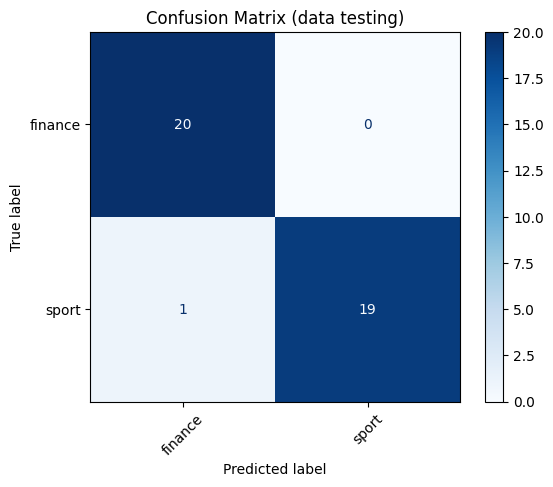

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nb = GaussianNB().fit(X_train, y_train)
pred = nb.predict(X_test)

print("Akurasi:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, zero_division=0))

labels = sorted(df["label"].unique())
ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=labels), display_labels=labels).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (data testing)"); plt.show()

In [17]:
import sys, pickle, joblib, importlib

APP_DIR = "klasifikasi-berita"          # sesuaikan dengan lokasi folder project
os.makedirs(f"{APP_DIR}/models", exist_ok=True)

# --- Simpan semua komponen yang dibutuhkan aplikasi ---
np.save(f"{APP_DIR}/models/skipgram_vectors.npy", W)               # bobot kata (kata x 100)
with open(f"{APP_DIR}/models/skipgram_vocab.pkl", "wb") as f:
    pickle.dump({"id2word": id2word, "word2id": word2id,
                 "vector_size": VECTOR_SIZE, "window": WINDOW, "epochs": EPOCHS}, f)
joblib.dump(nb, f"{APP_DIR}/models/naive_bayes.pkl")               # Gaussian Naive Bayes
with open(f"{APP_DIR}/models/preprocessing_config.pkl", "wb") as f:
    pickle.dump({"lowercase": True, "hapus_url": True, "hapus_simbol": True,
                 "hapus_angka": False, "hapus_stopword": True,
                 "stopwords": sorted(STOPWORDS)}, f)               # daftar stopword yang DIPAKAI saat training
print("Model tersimpan di", f"{APP_DIR}/models/")

Model tersimpan di klasifikasi-berita/models/


In [20]:
sys.path.insert(0, APP_DIR)
import src.preprocessing as prep
importlib.reload(prep)

# Muat ulang semua komponen dari disk
W2     = np.load(f"{APP_DIR}/models/skipgram_vectors.npy")
vocab2 = pickle.load(open(f"{APP_DIR}/models/skipgram_vocab.pkl", "rb"))
nb2    = joblib.load(f"{APP_DIR}/models/naive_bayes.pkl")
sw2    = set(pickle.load(open(f"{APP_DIR}/models/preprocessing_config.pkl", "rb"))["stopwords"])

# Cek 1: preprocessing file src/ menghasilkan token yang SAMA dengan notebook
tokens_cek = df["teks"].apply(lambda t: prep.preprocess(t, sw2))
assert (tokens_cek == df["tokens"]).all(), "Preprocessing src/ berbeda dari notebook!"
print("OK: preprocessing identik untuk semua", len(df), "berita")

# Cek 2: hasil prediksi dari model hasil muat ulang sama dengan sebelumnya
def doc_vec(tokens):
    ids = [vocab2["word2id"][t] for t in tokens if t in vocab2["word2id"]]
    return W2[ids].mean(axis=0) if ids else np.zeros(W2.shape[1])

X_test2 = np.vstack([doc_vec(d) for d in docs_test])
assert (nb2.predict(X_test2) == pred).all(), "Prediksi berbeda setelah load ulang!"
print("OK: prediksi identik setelah load ulang | kelas:", nb2.classes_)
print("Contoh probabilitas:", nb2.predict_proba(X_test2[:1]).round(4))

OK: preprocessing identik untuk semua 200 berita
OK: prediksi identik setelah load ulang | kelas: ['finance' 'sport']
Contoh probabilitas: [[1. 0.]]
